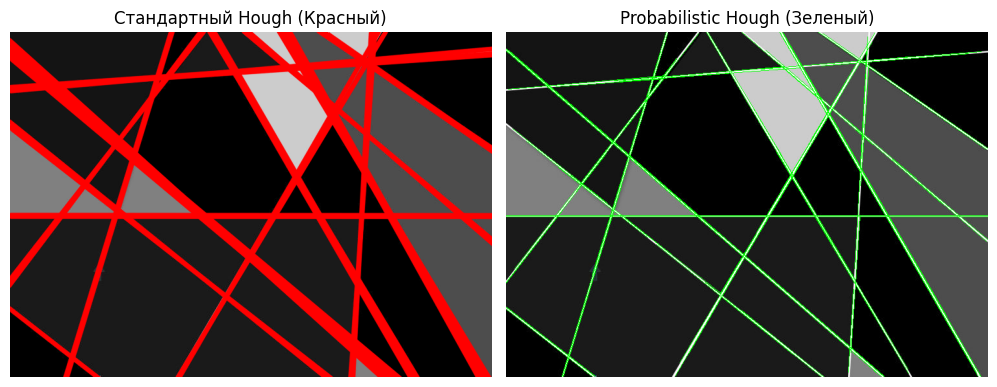

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import math

img = cv2.imread('data_img/lines.jpg')
img_original = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Детектируем границы с помощью алгоритма Canny
# Пороги: 50 (нижний) и 200 (верхний)
# Пиксели с градиентом выше 200 считаются границами, ниже 50 - игнорируются
# Пиксели между 50 и 200 считаются границами, если связаны с сильными границами
edges = cv2.Canny(gray, 50, 200, None, 3)

img_standard = img.copy()
img_probabilistic = img.copy()

# Функция HoughLines находит линии в полярных координатах (ρ, θ)
# Параметры:
# - edges: бинарное изображение с границами
# - 2: шаг по расстоянию ρ (в пикселях)
# - np.pi/180: шаг по углу θ (в радианах, здесь 1 градус)
# - 150: порог аккумулятора (минимальное количество голосов для линии)
lines = cv2.HoughLines(edges, 1, np.pi/180, 150, None, 0, 0)

if lines is not None:
    for i in range(0, len(lines)):
        rho = lines[i][0][0]
        theta = lines[i][0][1]
        a = math.cos(theta)
        b = math.sin(theta)
        x0 = a * rho
        y0 = b * rho
        pt1 = (int(x0 + 1000*(-b)), int(y0 + 1000*(a)))
        pt2 = (int(x0 - 1000*(-b)), int(y0 - 1000*(a)))
        cv2.line(img_standard, pt1, pt2, (0,0,255), 5, cv2.LINE_AA)

# Функция HoughLinesP находит отрезки линий (с началом и концом)
# Параметры:
# edges: бинарное изображение с границами
# 1: шаг по расстоянию ρ
# np.pi/180: шаг по углу θ
# 50: порог аккумулятора (минимальное количество голосов)
# 50: минимальная длина отрезка (пиксели)
# 10: максимальный разрыв между точками одной линии
lines_p = cv2.HoughLinesP(edges, rho=1, theta=np.pi / 180, threshold=50, minLineLength=100, maxLineGap=25)

# Перебираем все найденные отрезки
for x1, y1, x2, y2 in lines_p[:, 0]:
    # Рисуем отрезок на изображении вероятностным преобразованием Хафа
    cv2.line(img_probabilistic, (x1, y1), (x2, y2), (0, 255, 0), 1)

plt.figure(figsize=(20, 10))

plt.subplot(1, 4, 1)
plt.imshow(cv2.cvtColor(img_standard, cv2.COLOR_BGR2RGB))
plt.title('Стандартный Hough (Красный)')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(cv2.cvtColor(img_probabilistic, cv2.COLOR_BGR2RGB))
plt.title('Probabilistic Hough (Зеленый)')
plt.axis('off')

plt.tight_layout()
plt.show()

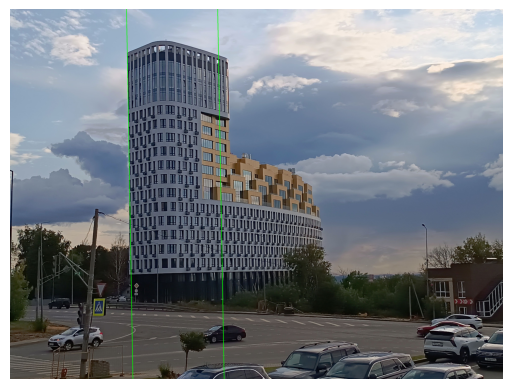

In [3]:
path_to_file = 'data_img/skyskeb_one.jpg'
img = cv2.imread(path_to_file, 0)
color_img = cv2.imread(path_to_file)

img = cv2.GaussianBlur(img, (3,3), 0)
edges = cv2.Canny(img, 50, 200)
lines = cv2.HoughLines(edges, 2, np.pi/180, 700)

# Допустимое отклонение от вертикали (в радианах)
vertical_angle = np.pi
angle_tolerance = np.pi / 12

multiplier = 4000

vertical_lines = []

for line in lines:
    rho, theta = line[0]
    if abs(theta - vertical_angle) < angle_tolerance or abs(theta + vertical_angle) < angle_tolerance:
        k1, k2 = np.cos(theta), np.sin(theta)
        x0, y0 = k1*rho, k2*rho
        x1, y1 = int(x0 + multiplier*(-k2)), int(y0 + multiplier*k1)
        x2, y2 = int(x0 - multiplier*(-k2)), int(y0 - multiplier*k1)
        vertical_lines.append((x1, y1, x2, y2))

vertical_lines.sort(key=lambda x: x[0])  # Сортируем по x1
cv2.line(color_img, (vertical_lines[0][0], vertical_lines[0][1]), (vertical_lines[0][2], vertical_lines[0][3]), (0, 255, 0), 3)
cv2.line(color_img, (vertical_lines[-1][0], vertical_lines[-1][1]), (vertical_lines[-1][2], vertical_lines[-1][3]), (0, 255, 0), 3)

plt.figure()
plt.imshow(cv2.cvtColor(color_img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

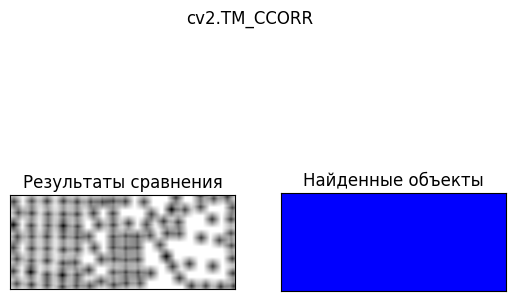

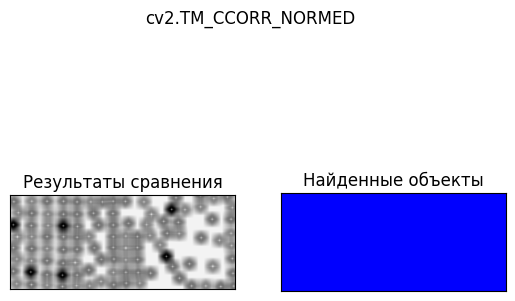

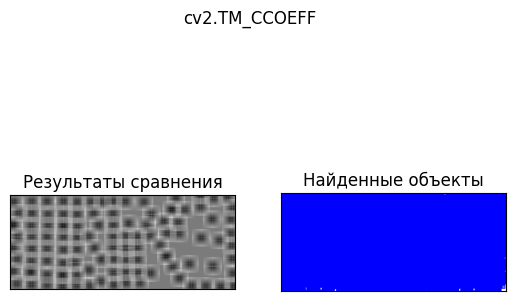

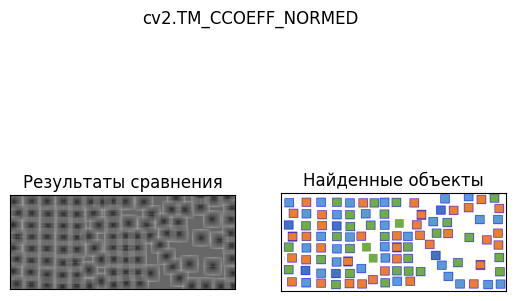

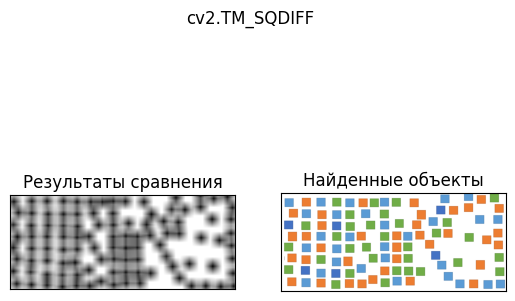

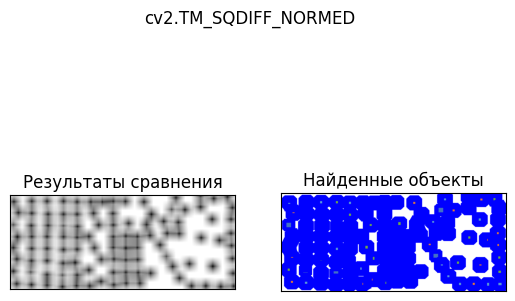

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


path_to_file = 'data_img/square_many.jpg'
path_to_file_2 = 'data_img/square.jpg'
pict_colour = cv2.imread(path_to_file)
pict_colour2 = pict_colour.copy()
pict = cv2.cvtColor(pict_colour, cv2.COLOR_BGR2GRAY)
pict2 = pict.copy()
template = cv2.imread(path_to_file_2, 0)
w, h = template.shape[::-1]
methods = ['cv2.TM_CCORR', 'cv2.TM_CCORR_NORMED', 'cv2.TM_CCOEFF',
'cv2.TM_CCOEFF_NORMED', 'cv2.TM_SQDIFF', 'cv2.TM_SQDIFF_NORMED']

for meth in methods:
    pict = pict2.copy()
    method = eval(meth)
    res = cv2.matchTemplate(pict, template, method) # Сравнение
    threshold = 0.8 
    
    if method in [cv2.TM_SQDIFF, cv2.TM_SQDIFF_NORMED]:
        loc = np.where(res <= (1 - threshold)) 
    else:
        loc = np.where(res >= threshold)
        
    pict_colour = pict_colour2.copy()

    for pt in zip(*loc[::-1]):
        br = (pt[0] + w, pt[1] + h)
        cv2.rectangle(pict_colour, pt, br, (255, 0, 0), 2) # Толщина 2, чтобы видеть много объектов
        
    plt.figure()
    plt.subplot(121); plt.imshow(res, cmap='gray'); plt.title('Результаты сравнения')
    plt.xticks([]); plt.yticks([])
    plt.subplot(122); plt.imshow(cv2.cvtColor(pict_colour, cv2.COLOR_BGR2RGB)); plt.title('Найденные объекты');
    plt.xticks([]); plt.yticks([]); plt.suptitle(meth)
    plt.show()

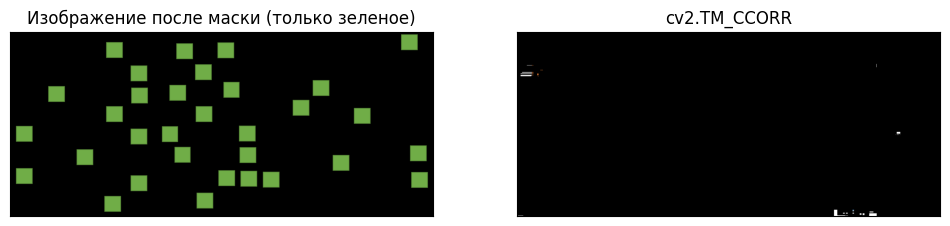

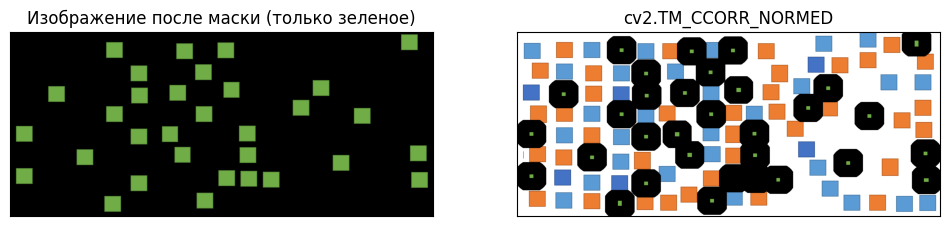

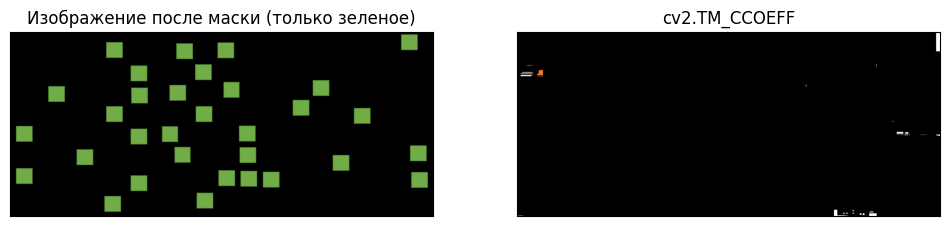

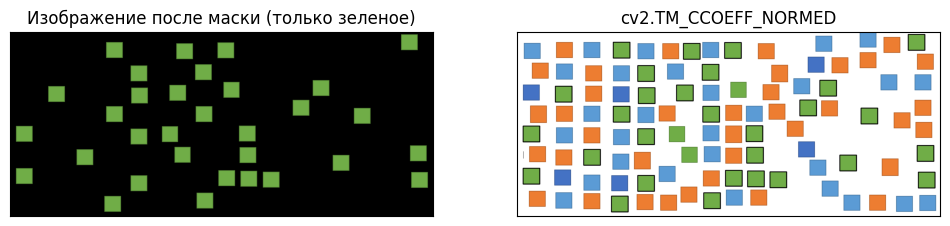

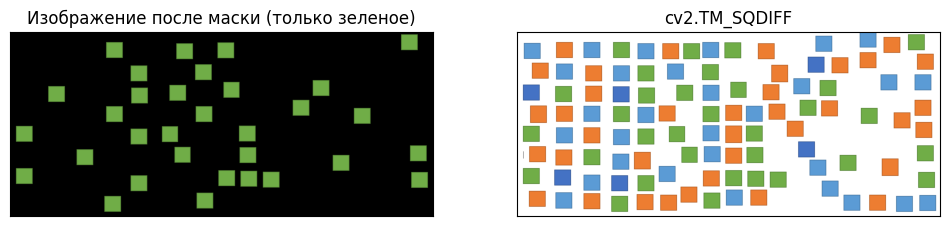

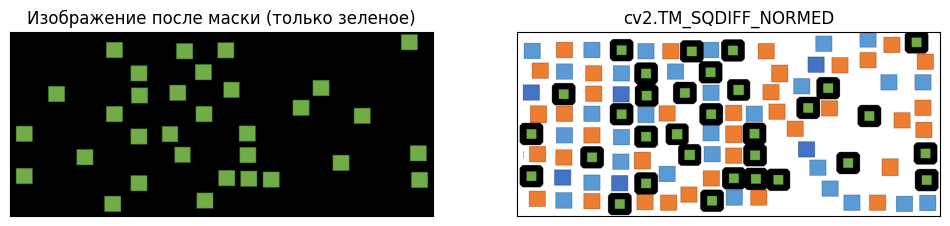

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

path_to_file = 'data_img/square_many.jpg'
path_to_file_2 = 'data_img/square.jpg'

pict_colour = cv2.imread(path_to_file)
pict_colour2 = pict_colour.copy()

hsv = cv2.cvtColor(pict_colour, cv2.COLOR_BGR2HSV)
lower_green = np.array([35, 40, 40])
upper_green = np.array([85, 255, 255])
mask = cv2.inRange(hsv, lower_green, upper_green)

masked_img = cv2.bitwise_and(pict_colour, pict_colour, mask=mask)

pict = cv2.cvtColor(masked_img, cv2.COLOR_BGR2GRAY)
template = cv2.imread(path_to_file_2, 0)
w, h = template.shape[::-1]

methods = ['cv2.TM_CCORR', 'cv2.TM_CCORR_NORMED', 'cv2.TM_CCOEFF',
           'cv2.TM_CCOEFF_NORMED', 'cv2.TM_SQDIFF', 'cv2.TM_SQDIFF_NORMED']

for meth in methods:
    method = eval(meth)
    res = cv2.matchTemplate(pict, template, method)
    
    threshold = 0.8 
    
    if method in [cv2.TM_SQDIFF, cv2.TM_SQDIFF_NORMED]:
        loc = np.where(res <= (1 - threshold)) 
    else:
        loc = np.where(res >= threshold)
        
    draw_img = pict_colour2.copy()

    for pt in zip(*loc[::-1]):
        br = (pt[0] + w, pt[1] + h)
        cv2.rectangle(draw_img, pt, br, (0, 0, 0), 2)
        
    plt.figure(figsize=(12, 5))
    plt.subplot(121)
    plt.imshow(cv2.cvtColor(masked_img, cv2.COLOR_BGR2RGB))
    plt.title('Изображение после маски (только зеленое)')
    plt.xticks([]); plt.yticks([])
    
    plt.subplot(122)
    plt.imshow(cv2.cvtColor(draw_img, cv2.COLOR_BGR2RGB))
    plt.title(f'{meth}')
    plt.xticks([]); plt.yticks([])
    plt.show()